## Project 2
Classification
10 points total

Program 1
Generate a dataset:
- 2 dimensions - x1, x2
- 4 classes (arbitrary)
- 50 data points per class, 200 total


The standard deviation, shape, and location of the cluster centers are left to your decision.
Divide the data into a training and testing sets in a 80/20 ratio.


Visualise the dataset.
Write and train three multi-class classifiers:
1. Using a combinations of binary perceptrons, with a
    - One-versus-one strategy, or
    - One-versus-rest strategy
2. Using logistic regression. Use the softmax function.

Visualise the accuracy of each classifier based on the test set.
Write a 1-2 sentence comparison of approaches.




In [387]:
from typing import Literal

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from numpy import ndarray

from matplotlib.lines import Line2D

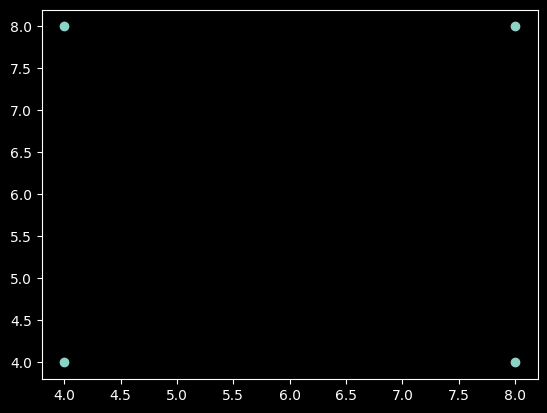

In [388]:
centroids = [(4, 4), (8,4), (4, 8), (8,8)]

standard_deviation = 0.9

x_centroids = [t[0] for t in centroids]
y_centroids = [t[1] for t in centroids]

plt.scatter([t[0] for t in centroids], [t[1] for t in centroids])

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


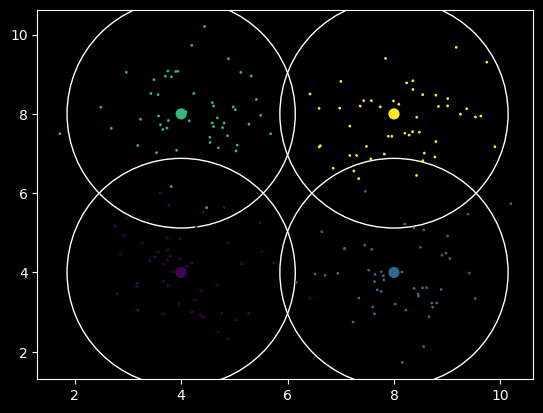

In [389]:
# generate data

# order between X and Y arrays has to be maintained
# X = features
X = []
# y = labels
y = []

samples_per_class = 50
dimensionality_of_features = 2

for i, centroid in enumerate(centroids):
    samples = np.random.randn(samples_per_class, dimensionality_of_features)
    samples = samples * standard_deviation + centroid
    X.append(samples)
    y.append([i] * samples_per_class)

X = np.concatenate(X)
y = np.concatenate(y)

print(type(X))
print(type(y))

a = ndarray

colors_of_centroids = np.unique(y)
colors_of_samples = y
size_of_centroids_range = standard_deviation * 1000 * 30
plt.scatter([t[0] for t in centroids], [t[1] for t in centroids], facecolors='none', edgecolors='white', s=size_of_centroids_range)
plt.scatter([t[0] for t in centroids], [t[1] for t in centroids], c=colors_of_centroids, s=50)
plt.scatter(X[:,0], X[:,1], c=colors_of_samples, s=1)

In [390]:
class Perceptron:

    def __init__(self, dimensionality, name="perceptron_x", activation_function = lambda x: 1 if x > 0 else 0):
        self.name = name
        # parameters
        self.weights = np.random.rand(dimensionality) * 2 - 1 # weights in range from -1 to 1
        self.bias = np.random.rand()
        self.learning_rate = 0.1
        self.epochs = 20
        self.activation = activation_function

        # metrics
        self.correct_classifications = 0
        self.all_classifications = 0

    def _forward(self, feature: np.ndarray) -> float:
        product = np.dot(feature, self.weights)
        product = product + self.bias
        result = self.activation(product)

        if self.activation == (lambda x: 1 if x > 0 else 0):
            assert result in [0,1], "Perceptron should be binary."

        return result

    def _backwards(self, feature: np.ndarray, error: float):

        self.all_classifications += 1
        self.correct_classifications += abs(abs(error) - 1)

        self.bias += error * self.learning_rate
        for dimension in range(len(self.weights)):
            self.weights[dimension] += feature[dimension] * error * self.learning_rate

    def learn(self, features: np.ndarray, labels: np.ndarray):
        for epoch in range(0,self.epochs):
            for feature, label in zip(features,labels):
                # predict
                predicted_label = self._forward(feature)
                # compute error of prediction
                error = round(label - predicted_label, 5)
                # adjust Perceptron according to erro
                self._backwards(feature, error)
            # print("epoch: " + str(epoch) + " | accuracy: " + str(self.correct_classifications / self.all_classifications))
            self.all_classifications = 0
            self.correct_classifications = 0


    def predict(self, features: np.ndarray) -> np.ndarray:
        predicted_labels = [self._forward(feature) for feature in features]
        return np.array(predicted_labels)

In [426]:
def plot_perceptron_boundary(ax, perceptron: Perceptron, color: str, label: str, x_limits: tuple[float, float]):
    w_0, w_1 = perceptron.weights

    x_values = np.array(x_limits)
    y_values = -(w_0 * x_values + perceptron.bias) / w_1
    ax.plot(x_values, y_values, color=color, linestyle='--', linewidth=1, alpha=0.8, label=label)

### perceptron smoke test

In [397]:
def yield_accuracy_of_predictions(p: Perceptron, features_set, labels_set):
    predictions = p.predict(X)
    correct = 0

    for true_label, prediction in zip(y, predictions):
        if true_label == prediction:
            correct += 1

    return str(correct / len(predictions))

test_perceptron = Perceptron(dimensionality=2)

accuracy = yield_accuracy_of_predictions(p=test_perceptron, features_set=X, labels_set=y)
print("accuracy: " + accuracy)
assert (0.20 < float(accuracy) < 0.30), "A single four-class perceptron without any training should have 25% accuracy."

accuracy: 0.25


#### experimental strategy : one-vs-rest binary classifiers with output space {0,1}

Accuracy of One vs Rest Experimental : 0.625


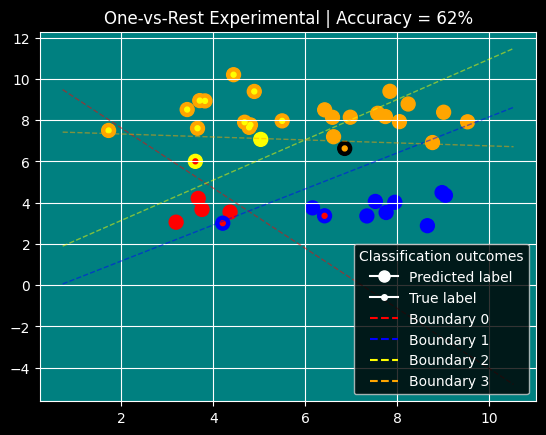

In [427]:
features_train_set, features_test_set, labels_train_set, labels_test_set = train_test_split(X,y, test_size=0.2)

# Perceptron 0
y_0 = np.array([1 if e == 0 else 0 for e in labels_train_set])
perceptron_0 = Perceptron(dimensionality=2, name="perceptron_0")
perceptron_0.learn(features_train_set,y_0)
# print("Perceptron 0 weights: " + str(perceptron_0.weights))
# Perceptron 1
y_1 = np.array([1 if e == 1 else 0 for e in labels_train_set])
perceptron_1 = Perceptron(dimensionality=2, name="perceptron_1")
perceptron_1.learn(features_train_set,y_1)
# print("Perceptron 1 weights: " + str(perceptron_1.weights))
# Perceptron 2
y_2 = np.array([1 if e == 2 else 0 for e in labels_train_set])
perceptron_2 = Perceptron(dimensionality=2, name="perceptron_2")
perceptron_2.learn(features_train_set,y_2)
# print("Perceptron 2 weights: " + str(perceptron_2.weights))
# Perceptron 3
y_3 = np.array([1 if e == 3 else 0 for e in labels_train_set])
perceptron_3 = Perceptron(dimensionality=2, name="perceptron_3")
perceptron_3.learn(features_train_set,y_3)
# print("Perceptron 3 weights: " + str(perceptron_3.weights))


def one_vs_rest_classification(features: np.ndarray) -> list[Literal[0,1,2,3]]:
    predicted_labels = []
    perceptron_label_dict = { perceptron_0: 0, perceptron_1: 1, perceptron_2: 2, perceptron_3: 3}

    for feature in features:
        predicted_l = -1
        owner = "Nobody"
        for perceptron in perceptron_label_dict:
            if perceptron.predict(np.array([feature])) == 1:
                predicted_l = perceptron_label_dict.get(perceptron)
                owner = perceptron.name

        predicted_labels.append(predicted_l)
        # print(owner + " claims that it's his label: " + str(predicted_l))
        # print("Perceptron 0 output:" + str(perceptron_0.predict(np.array([feature]))), end=" | ")
        # print("Perceptron 1 output:" + str(perceptron_1.predict(np.array([feature]))), end=" | ")
        # print("Perceptron 2 output:" + str(perceptron_2.predict(np.array([feature]))), end=" | ")
        # print("Perceptron 3 output:" + str(perceptron_3.predict(np.array([feature]))))
    return predicted_labels

predicted_labels_list = one_vs_rest_classification(features_test_set)

assert len(predicted_labels_list) == len(labels_test_set)

correct = 0
for predicted_label, true_label in zip(predicted_labels_list, labels_test_set):
    # print("Predicted label: " + str(predicted_label), end=" | ")
    # print("True label: " + str(true_label))
    if predicted_label == true_label:
        correct += 1

accuracy = correct/len(labels_test_set)
print("Accuracy of One vs Rest Experimental : " + str(accuracy))

colors_labels_map = {-1: 'black', 0: 'red', 1: 'blue', 2: 'yellow', 3: 'orange'}

fig, ax = plt.subplots()

scatter_predicted_labels = ax.scatter(
    x=features_test_set[:,0],
    y=features_test_set[:,1],
    marker="o",
    c=[colors_labels_map[label] for label in predicted_labels_list],
    s=100)

scatter_true_labels = ax.scatter(
    x=features_test_set[:,0],
    y=features_test_set[:,1],
    c=[colors_labels_map[label] for label in labels_test_set],
    marker=".",
    s=50)

x_limits = (features_test_set[:,0].min() - 1, features_test_set[:,0].max() + 1)
plot_perceptron_boundary(ax, perceptron_0, 'red', 'Boundary 0', x_limits)
plot_perceptron_boundary(ax, perceptron_1, 'blue', 'Boundary 1', x_limits)
plot_perceptron_boundary(ax, perceptron_2, 'yellow', 'Boundary 2', x_limits)
plot_perceptron_boundary(ax, perceptron_3, 'orange', 'Boundary 3', x_limits)

plt.gca().set_facecolor('teal')
ax.grid(True)
ax.set_title("One-vs-Rest Experimental | Accuracy = " + str(int(accuracy * 100)) + "%")

legend_elements = [
      Line2D([0], [0], marker='o', color='w', label='Predicted label', markersize=8),
      Line2D([0], [0], marker='.', color='w', label='True label', markersize=8),
      Line2D([0], [0], color='red', linestyle='--', label='Boundary 0'),
      Line2D([0], [0], color='blue', linestyle='--', label='Boundary 1'),
      Line2D([0], [0], color='yellow', linestyle='--', label='Boundary 2'),
      Line2D([0], [0], color='orange', linestyle='--', label='Boundary 3')
]

ax.legend(handles=legend_elements, title="Classification outcomes", loc='lower right')

plt.show()

### strategy 1b : one-vs-rest binary classifiers with output space [0, 1]

Accuracy of One vs Rest : 0.925


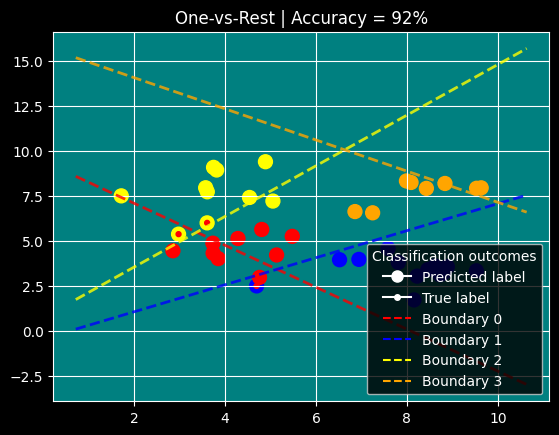

In [416]:
features_train_set, features_test_set, labels_train_set, labels_test_set = train_test_split(X,y, test_size=0.2)

sigmoid_function = lambda x: 1 / (1 + np.exp(-x))

# Perceptron 0
y_0 = np.array([1 if e == 0 else 0 for e in labels_train_set])
perceptron_0 = Perceptron(dimensionality=2, name="perceptron_0", activation_function=sigmoid_function)
perceptron_0.learn(features_train_set,y_0)
# print("Perceptron 0 weights: " + str(perceptron_0.weights))
# Perceptron 1
y_1 = np.array([1 if e == 1 else 0 for e in labels_train_set])
perceptron_1 = Perceptron(dimensionality=2, name="perceptron_1", activation_function=sigmoid_function)
perceptron_1.learn(features_train_set,y_1)
# print("Perceptron 1 weights: " + str(perceptron_1.weights))
# Perceptron 2
y_2 = np.array([1 if e == 2 else 0 for e in labels_train_set])
perceptron_2 = Perceptron(dimensionality=2, name="perceptron_2", activation_function=sigmoid_function)
perceptron_2.learn(features_train_set,y_2)
# print("Perceptron 2 weights: " + str(perceptron_2.weights))
# Perceptron 3
y_3 = np.array([1 if e == 3 else 0 for e in labels_train_set])
perceptron_3 = Perceptron(dimensionality=2, name="perceptron_3", activation_function=sigmoid_function)
perceptron_3.learn(features_train_set,y_3)
# print("Perceptron 3 weights: " + str(perceptron_3.weights))


def one_vs_rest_classification(features: np.ndarray) -> list[Literal[0,1,2,3]]:
    predicted_labels = []
    perceptron_label_dict = { perceptron_0: 0, perceptron_1: 1, perceptron_2: 2, perceptron_3: 3}

    for feature in features:
        predicted_l = -1
        owner = "Nobody"
        current_max = -1
        for perceptron in perceptron_label_dict:
            degree_of_confidence = perceptron.predict(np.array([feature]))
            if degree_of_confidence > current_max:
                current_max = degree_of_confidence
                predicted_l = perceptron_label_dict.get(perceptron)
                owner = perceptron.name

        predicted_labels.append(predicted_l)
        # print(owner + " claims that it's his label: " + str(predicted_l))
        # print("Perceptron 0 output:" + str(perceptron_0.predict(np.array([feature]))), end=" | ")
        # print("Perceptron 1 output:" + str(perceptron_1.predict(np.array([feature]))), end=" | ")
        # print("Perceptron 2 output:" + str(perceptron_2.predict(np.array([feature]))), end=" | ")
        # print("Perceptron 3 output:" + str(perceptron_3.predict(np.array([feature]))))
    return predicted_labels

predicted_labels_list = one_vs_rest_classification(features_test_set)

assert len(predicted_labels_list) == len(labels_test_set)

correct = 0
for predicted_label, true_label in zip(predicted_labels_list, labels_test_set):
    # print("Predicted label: " + str(predicted_label), end=" | ")
    # print("True label: " + str(true_label))
    if predicted_label == true_label:
        correct += 1

accuracy = correct/len(labels_test_set)

print("Accuracy of One vs Rest : " + str(accuracy))

colors_labels_map = {-1: 'black', 0: 'red', 1: 'blue', 2: 'yellow', 3: 'orange'}


fig, ax = plt.subplots()

scatter_predicted_labels = ax.scatter(
    x=features_test_set[:,0],
    y=features_test_set[:,1],
    marker="o",
    c=[colors_labels_map[label] for label in predicted_labels_list],
    s=100)

scatter_true_labels = ax.scatter(
    x=features_test_set[:,0],
    y=features_test_set[:,1],
    c=[colors_labels_map[label] for label in labels_test_set],
    marker=".",
    s=50)

x_limits = (features_test_set[:,0].min() - 1, features_test_set[:,0].max() + 1)
plot_perceptron_boundary(ax, perceptron_0, 'red', 'Boundary 0', x_limits)
plot_perceptron_boundary(ax, perceptron_1, 'blue', 'Boundary 1', x_limits)
plot_perceptron_boundary(ax, perceptron_2, 'yellow', 'Boundary 2', x_limits)
plot_perceptron_boundary(ax, perceptron_3, 'orange', 'Boundary 3', x_limits)

plt.gca().set_facecolor('teal')
ax.grid(True)
ax.set_title("One-vs-Rest | Accuracy = " + str(int(accuracy * 100)) + "%")

legend_elements = [
      Line2D([0], [0], marker='o', color='w', label='Predicted label', markersize=8),
      Line2D([0], [0], marker='.', color='w', label='True label', markersize=8),
      Line2D([0], [0], color='red', linestyle='--', label='Boundary 0'),
      Line2D([0], [0], color='blue', linestyle='--', label='Boundary 1'),
      Line2D([0], [0], color='yellow', linestyle='--', label='Boundary 2'),
      Line2D([0], [0], color='orange', linestyle='--', label='Boundary 3')
]

ax.legend(handles=legend_elements, title="Classification outcomes", loc='lower right')

plt.show()

### strategy 1a : one-vs-one binary classifiers with output space {0,1}

Accuracy of One vs One : 0.325


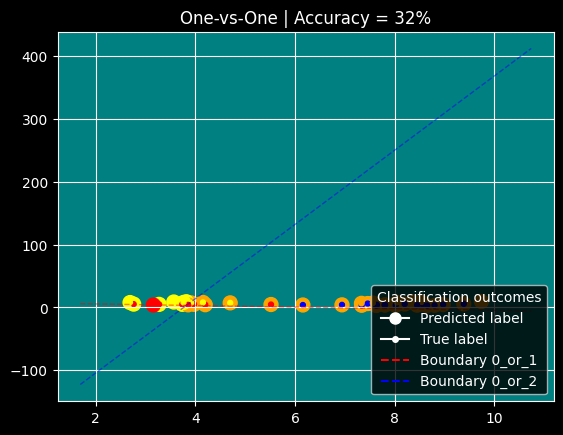

In [432]:
features_train_set, features_test_set, labels_train_set, labels_test_set = train_test_split(X,y, test_size=0.2)

sigmoid_function = lambda x: 1 / (1 + np.exp(-x))

# Perceptron 0_or_1
y_0_or_1 = np.array([1 if e == 0 or e == 0 else 0 for e in labels_train_set])
perceptron_0_or_1 = Perceptron(dimensionality=2, name="perceptron_0_or_1")
perceptron_0_or_1.learn(features_train_set,y_0_or_1)

# Perceptron 2_or_3
y_0_or_2 = np.array([1 if e == 0 or e == 2 else 0 for e in labels_train_set])
perceptron_0_or_2 = Perceptron(dimensionality=2, name="perceptron_0_or_2")
perceptron_0_or_2.learn(features_train_set,y_0_or_2)


def one_vs_one_classification(features: np.ndarray) -> list[Literal[0,1,2,3]]:
    predicted_labels = []

    for feature in features:
        is_0_or_1: bool = True if 1 == perceptron_0_or_1.predict(np.array([feature])) else False
        is_0_or_2: bool = True if 1 == perceptron_0_or_2.predict(np.array([feature])) else False

        if is_0_or_1:
            if is_0_or_2:
                precited_l = 0
            else:
                precited_l = 1
        else:
            if is_0_or_2:
                precited_l = 2
            else:
                precited_l = 3

        predicted_labels.append(precited_l)

    return predicted_labels

predicted_labels_list = one_vs_one_classification(features_test_set)

assert len(predicted_labels_list) == len(labels_test_set)

correct = 0
for predicted_label, true_label in zip(predicted_labels_list, labels_test_set):
    # print("Predicted label: " + str(predicted_label), end=" | ")
    # print("True label: " + str(true_label))
    if predicted_label == true_label:
        correct += 1

accuracy = correct/len(labels_test_set)

print("Accuracy of One vs One : " + str(accuracy))

colors_labels_map = {0: 'red', 1: 'blue', 2: 'yellow', 3: 'orange'}

fig, ax = plt.subplots()

scatter_predicted_labels = ax.scatter(
    x=features_test_set[:,0],
    y=features_test_set[:,1],
    marker="o",
    c=[colors_labels_map[label] for label in predicted_labels_list],
    s=100)

scatter_true_labels = ax.scatter(
    x=features_test_set[:,0],
    y=features_test_set[:,1],
    c=[colors_labels_map[label] for label in labels_test_set],
    marker=".",
    s=50)

x_limits = (features_test_set[:,0].min() - 1, features_test_set[:,0].max() + 1)
plot_perceptron_boundary(ax, perceptron_0_or_1, 'red', 'Boundary 0_or_1', x_limits)
plot_perceptron_boundary(ax, perceptron_0_or_2, 'blue', 'Boundary 0_or_2', x_limits)

plt.gca().set_facecolor('teal')
ax.grid(True)
ax.set_title("One-vs-One | Accuracy = " + str(int(accuracy * 100)) + "%")

legend_elements = [
      Line2D([0], [0], marker='o', color='w', label='Predicted label', markersize=8),
      Line2D([0], [0], marker='.', color='w', label='True label', markersize=8),
      Line2D([0], [0], color='red', linestyle='--', label='Boundary 0_or_1'),
      Line2D([0], [0], color='blue', linestyle='--', label='Boundary 0_or_2')
]

ax.legend(handles=legend_elements, title="Classification outcomes", loc='lower right')

plt.show()